# Quadratic-program bounds for two partial traces

This notebook has two goals:

1. reproduce the paper's numerical examples and checks;
2. let readers compute bounds for any spectrum of an equal bipartite system.

The implementation is deliberately small. The reusable functions are in
`partial_trace_qp.py`; this notebook only explains and exercises them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from partial_trace_qp import (
    dimension_renyi_bound,
    plateau_patterns,
    reference_p_bounds,
    renyi_lower_bound,
    schatten_bounds,
    solve_spectrum,
)

np.set_printoptions(precision=9, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

## The quadratic program

For multiplicities \(m=(m_1,\ldots,m_r)\), expand the reduced variables as

\[
\mu(x)=(\underbrace{x_1,\ldots,x_1}_{m_1},\ldots,
         \underbrace{x_r,\ldots,x_r}_{m_r}).
\]

The solver minimizes

\[
\|\mu(x)\|_2^2=\sum_jm_jx_j^2
\]

subject to decreasing order and \(\lambda\preceq\mu\): all prefix inequalities
and equality of the total sums. For entropy calculations, \(\mu\ge0\) can be
imposed with `nonnegative=True`.

The plateau families depend only on \(d\). The label `mu_k` means that the
constant plateau begins at entry \(k\) (using one-based mathematical indexing).

In [2]:
for d in range(3, 8):
    print(f"d={d}: {plateau_patterns(d)}")

d=3: {'mu_1': (6, 1, 1, 1), 'mu_2': (1, 6, 1, 1), 'mu_3': (1, 1, 6, 1), 'mu_4': (1, 1, 1, 6)}
d=4: {'mu_2': (1, 12, 1, 1, 1), 'mu_3': (1, 1, 12, 1, 1), 'mu_4': (1, 1, 1, 12, 1)}
d=5: {'mu_3': (1, 1, 20, 1, 1, 1), 'mu_4': (1, 1, 1, 20, 1, 1)}
d=6: {'mu_4': (1, 1, 1, 30, 1, 1, 1)}
d=7: {'mu_4': (1, 1, 1, 43, 1, 1, 1)}


In [3]:
def print_results(results):
    print(f"{'family':<8} {'objective':>12}  reduced variables")
    for name, result in results.items():
        print(
            f"{name:<8} {result.objective:12.9f}  {result.reduced}"
        )


def plot_p_bounds(lam, results, p_values=range(1, 11)):
    p_values = np.asarray(list(p_values))
    references = {
        name: [reference_p_bounds(lam, float(p))[name] for p in p_values]
        for name in ("Audenaert", "Rastegin")
    }
    candidates = {
        name: [schatten_bounds(results, float(p))[name] for p in p_values]
        for name in results
    }

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    ax.plot(p_values, references["Audenaert"], "x--", label="Audenaert")
    ax.plot(p_values, references["Rastegin"], "x-", color="black", label="Rastegin")
    for name, values in candidates.items():
        ax.plot(p_values, values, marker="o", label=name)
    ax.set(
        title=r"Bounds for $\|\mathrm{tr}_1\rho\|_p^p+\|\mathrm{tr}_2\rho\|_p^p$",
        xlabel=r"$p$",
        ylabel="upper bound",
    )
    ax.legend()
    plt.show()

## Reproducing the worked \(d=3\) spectrum

Calling `solve_spectrum` is enough: it infers \(d=3\) from the nine
eigenvalues and solves all four admissible plateau families.

family      objective  reduced variables
mu_1      1.000000000  [ 0.333333333 -0.333333333 -0.333333333 -0.333333333]
mu_2      0.277777778  [ 0.444444444  0.111111111 -0.055555556 -0.055555556]
mu_3      0.221424501  [ 0.333333333  0.282051282  0.07008547  -0.035897436]
mu_4      0.256296296  [0.333333333 0.266666667 0.266666667 0.022222222]


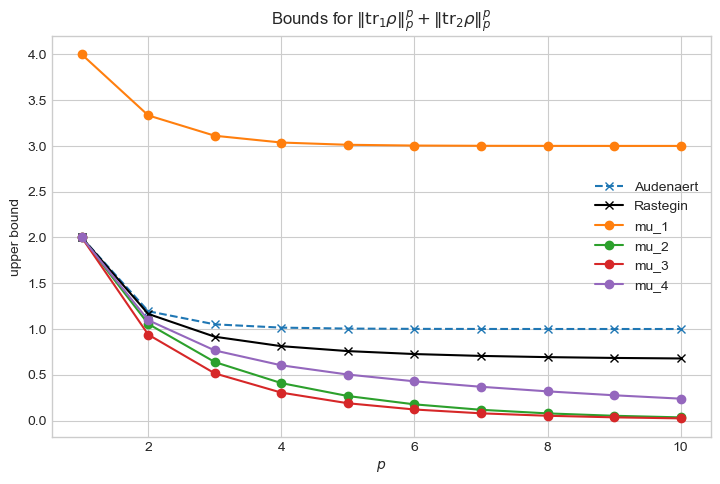

In [4]:
lambda_3 = np.array([15, 10, 5, 4, 3, 3, 2, 2, 1], dtype=float) / 45
results_3 = solve_spectrum(lambda_3)

print_results(results_3)
plot_p_bounds(lambda_3, results_3)

For Rényi entropies the candidate spectrum must be nonnegative. Infeasible
families are omitted automatically; comparing the two key sets below makes
that visible.

all families:        ['mu_1', 'mu_2', 'mu_3', 'mu_4']
nonnegative families: ['mu_2', 'mu_3', 'mu_4']


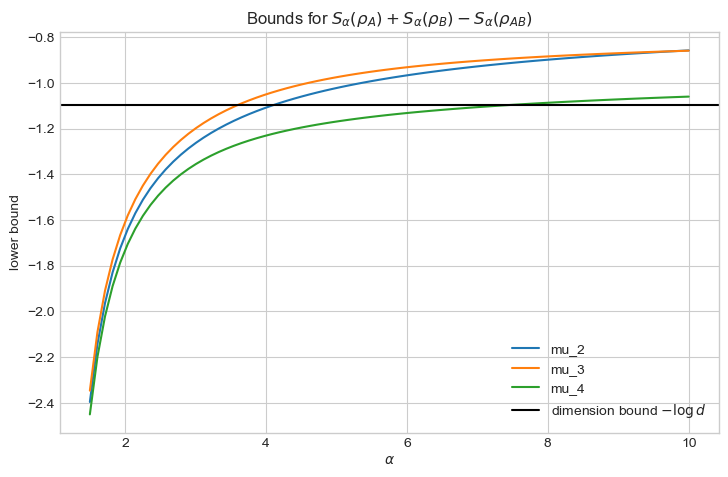

In [5]:
positive_3 = solve_spectrum(lambda_3, nonnegative=True)
print("all families:       ", sorted(results_3))
print("nonnegative families:", sorted(positive_3))

alphas = np.linspace(1.5, 10, 80)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for name, result in positive_3.items():
    values = [renyi_lower_bound(lambda_3, result.spectrum, a) for a in alphas]
    ax.plot(alphas, values, label=name)
ax.axhline(
    dimension_renyi_bound(lambda_3),
    color="black",
    label=r"dimension bound $-\log d$",
)
ax.set(
    title=r"Bounds for $S_\alpha(\rho_A)+S_\alpha(\rho_B)-S_\alpha(\rho_{AB})$",
    xlabel=r"$\alpha$",
    ylabel="lower bound",
)
ax.legend()
plt.show()

## Automatic higher-dimensional computation

This \(d=6\) density spectrum does not initially have the required plateau.
The same one-line call now selects the single higher-dimensional plateau
family and constructs a valid majorizer.

family      objective  reduced variables
mu_4      0.066587131  [0.2         0.08536193  0.08536193  0.019276139 0.016997319 0.016997319
 0.016997319]


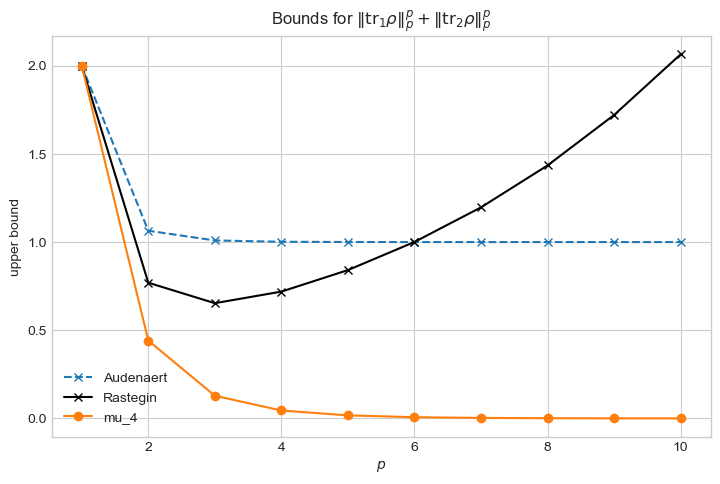

In [6]:
lambda_6 = np.r_[0.20, 0.08, 0.06, 0.05, np.full(32, 0.0190625)]
results_6 = solve_spectrum(lambda_6, nonnegative=True)

print_results(results_6)
plot_p_bounds(lambda_6, results_6)

## Use your own spectrum

Only the spectrum needs to change. Its length must be \(d^2\) for an integer
\(d\ge3\). The values may be any real numbers for the general self-adjoint
calculation; use a nonnegative trace-one spectrum for the density-matrix
comparison functions.

family      objective  reduced variables
mu_1      0.253333333  [ 0.2         -0.066666667 -0.066666667 -0.066666667]
mu_2      0.286153846  [ 0.384615385  0.138461538 -0.107692308 -0.107692308]
mu_3      0.280000000  [ 0.3  0.3  0.1 -0.2]
mu_4      0.333333333  [0.333333333 0.333333333 0.333333333 0.         ]


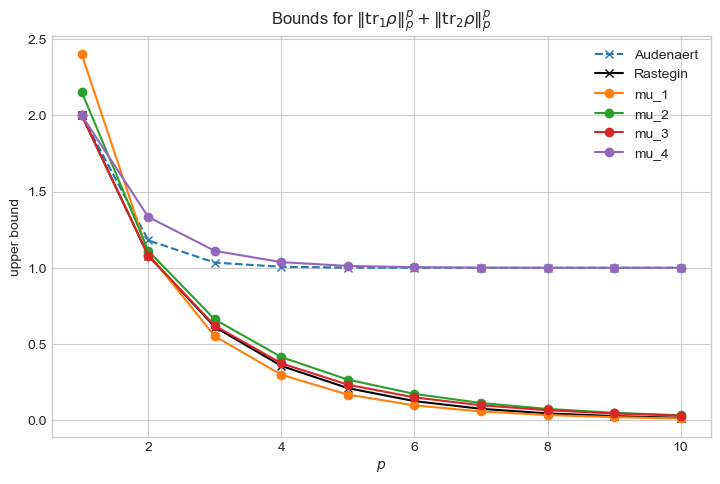

In [12]:
lambda_new = np.asarray([0.2, 0.2, 0.2, 0.2, 0.1, 0.1, 0, 0 ,0], dtype=float)
results_new = solve_spectrum(lambda_new)
print_results(results_new)

# For density matrices and entropy bounds:
positive_new = solve_spectrum(lambda_new, nonnegative=True)
plot_p_bounds(lambda_new, results_new)